<a href="https://colab.research.google.com/github/ayesha-ml/urdu-nlp-pipeline/blob/main/i23_2503_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment no.02
## NLP
- --
#### Name: Ayesha Amer
#### Roll no. 23i-2503
#### Section: DS-6C
- --
### Libraries Loading

In [1]:
#importing all required libraries
import os
import json
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

### Data Loading

In [2]:
#loading cleaned.txt
f = open('cleaned.txt', 'r', encoding='utf-8')
cleaned_text = f.read()
f.close()

#loading raw.txt
f = open('raw.txt', 'r', encoding='utf-8')
raw_text = f.read()
f.close()

#loading metadata
f = open('Metadata.json', 'r', encoding='utf-8')
metadata = json.load(f)
f.close()

print('cleaned text length:', len(cleaned_text))
print('raw text length:', len(raw_text))
print('metadata entries:', len(metadata))

cleaned text length: 2132293
raw text length: 2170160
metadata entries: 275


- --
## Part 1 : Word Embeddings
## 1.1: TF-IDF
- Creatig a Documents List.

In [3]:
#splitting cleaned text into documents
documents = []
for line in cleaned_text.strip().split('\n'):
    line = line.strip()
    #removing the article heading
    if len(line) > 0 and not line.startswith('Article'):
        documents.append(line)

print('total documents:', len(documents))

#printing
for i in range(min(3, len(documents))):
    print('document', i+1, ':', documents[i][:150])

total documents: 17326
document 1 : انڈیا سے پاکستان آ کر شادی کرنے والی خاتون سربجیت کور نور فاطمہ نے کہا ہے کہ وہ اپنی باقی ماندہ زندگی پاکستان میں ہی ہنسی خوشی گزارنا چاہتا ہیں اور وہ
document 2 : وسطی پنجاب کے ضلع شیخوپورہ میں اپنے وکیل احمد حسن پاشا کے چیمبر میں میڈیا کے نمائند سے گفتگو کرتے ہوئے سربجیت کور نور فاطمہ کا مزید کہنا تھا کہ میں او
document 3 : ہم پیار کرتے ہوئے آٹھ سال ہو گئے تھے اور یہ یقین تھا کہ ہم دون کبھی نہ کبھی تو ضرور مل گے ۔


- Tokenizing

In [4]:
#tokenizing all documents
tokenized_docs = []
for doc in documents:
    tokens = doc.split()
    tokenized_docs.append(tokens)

print('total tokenized documents:', len(tokenized_docs))
print('first document tokens:', tokenized_docs[0][:15])
print('second document tokens:', tokenized_docs[1][:15])
print('third document tokens:', tokenized_docs[2][:15])

total tokenized documents: 17326
first document tokens: ['انڈیا', 'سے', 'پاکستان', 'آ', 'کر', 'شادی', 'کرنے', 'والی', 'خاتون', 'سربجیت', 'کور', 'نور', 'فاطمہ', 'نے', 'کہا']
second document tokens: ['وسطی', 'پنجاب', 'کے', 'ضلع', 'شیخوپورہ', 'میں', 'اپنے', 'وکیل', 'احمد', 'حسن', 'پاشا', 'کے', 'چیمبر', 'میں', 'میڈیا']
third document tokens: ['ہم', 'پیار', 'کرتے', 'ہوئے', 'آٹھ', 'سال', 'ہو', 'گئے', 'تھے', 'اور', 'یہ', 'یقین', 'تھا', 'کہ', 'ہم']


- Building Vocabulary

In [5]:
#counting word frequencies across all documents
all_words = []
for tokens in tokenized_docs:
    for token in tokens:
        all_words.append(token)

word_counts = Counter(all_words)

print('total words collected:', len(all_words))
print('unique words:', len(word_counts))
print('top 10 most common words:')
for i, (word, count) in enumerate(word_counts.most_common(10)):
    print(' ', i+1, ':', word, '->', count, 'times')

total words collected: 491022
unique words: 13495
top 10 most common words:
  1 : کے -> 20937 times
  2 : ۔ -> 16642 times
  3 : میں -> 14364 times
  4 : کی -> 13437 times
  5 : ہے -> 9924 times
  6 : سے -> 9697 times
  7 : اور -> 9465 times
  8 : کہ -> 8507 times
  9 : کا -> 7431 times
  10 : نے -> 7032 times


In [6]:
#restricting vocabulary to top 10000 tokens
vocab_size = 10000
most_common = word_counts.most_common(vocab_size)
vocab = ['<UNK>']
for word, count in most_common:
    vocab.append(word)

word_to_index = {}
for i in range(len(vocab)):
    word_to_index[vocab[i]] = i

print('vocabulary size:', len(vocab))
print('first 10 words in vocab:')
for i in range(min(10, len(vocab))):
    print(' ', i, ':', vocab[i])

vocabulary size: 10001
first 10 words in vocab:
  0 : <UNK>
  1 : کے
  2 : ۔
  3 : میں
  4 : کی
  5 : ہے
  6 : سے
  7 : اور
  8 : کہ
  9 : کا


- TF for each Doc

In [7]:
num_docs = len(tokenized_docs)
num_vocab = len(vocab)

print('number of documents:', num_docs)
print('vocabulary size:', num_vocab)

#building term-document matrix
tf_matrix = np.zeros((num_vocab, num_docs))

for doc_idx in range(num_docs):
    #getting the current document
    tokens = tokenized_docs[doc_idx]

    #counting how many times each word appears in this document
    token_count = Counter(tokens)
    total_tokens = len(tokens)

    for token in token_count:
        if token in word_to_index:
            word_idx = word_to_index[token]
        else:
            word_idx = word_to_index['<UNK>']
        tf_matrix[word_idx][doc_idx] = token_count[token] / total_tokens

print('tf matrix shape:', tf_matrix.shape)
print('tf value for word at index 1 in doc 0:', tf_matrix[1][0])

number of documents: 17326
vocabulary size: 10001
tf matrix shape: (10001, 17326)
tf value for word at index 1 in doc 0: 0.024390243902439025


- DF for each word

In [8]:
#computing document frequency  for each word
df = np.zeros(num_vocab)
for word_idx in range(num_vocab):
    count = 0
    for doc_idx in range(num_docs):
        if tf_matrix[word_idx][doc_idx] > 0:
            count = count + 1
    df[word_idx] = count

print('DF complete')
print('word index 1 appears in', df[1], 'documents')
print('unknown token appears in', df[0], 'documents')

DF complete
word index 1 appears in 11314.0 documents
unknown token appears in 2531.0 documents


- IDF

In [9]:
#computing idf
idf = np.zeros(num_vocab)
for word_idx in range(num_vocab):
    idf[word_idx] = math.log(num_docs / (1 + df[word_idx]))

print('idf complete')
print('idf for word index 1 is', round(idf[1], 4))
print('idf for unknown token is', round(idf[0], 4))

idf complete
idf for word index 1 is 0.4261
idf for unknown token is 1.9232


- TF_IDF matrix

In [10]:
#computing tfidf matrix
tfidf_matrix = np.zeros((num_vocab, num_docs))
for word_idx in range(num_vocab):
    for doc_idx in range(num_docs):
        tfidf_matrix[word_idx][doc_idx] = tf_matrix[word_idx][doc_idx] * idf[word_idx]

#saving tfidf matrix
np.save('tfidf_matrix.npy', tfidf_matrix)
print('tfidf matrix saved, shape:', tfidf_matrix.shape)

tfidf matrix saved, shape: (10001, 17326)


- Top 10 most discriminative words per topic

In [11]:
#reporting top 10 most discriminative words per topic
#grouping documents by topic from metadata
topic_docs = {}
for item in metadata:
    topic = item.get('topic', item.get('category', 'unknown'))
    doc_id = item.get('id', item.get('doc_id', None))
    if topic not in topic_docs:
        topic_docs[topic] = []
    if doc_id is not None:
        topic_docs[topic].append(doc_id)

print('topics found:', list(topic_docs.keys()))

topics found: ['unknown']


In [12]:
#computing average tfidf score per word per topic
for topic in topic_docs:
    doc_indices = topic_docs[topic]
    valid_indices = []
    for idx in doc_indices:
        if idx < num_docs:
            valid_indices.append(idx)
    if len(valid_indices) == 0:
        continue
    #average tfidf across docs in this topic
    topic_tfidf = np.zeros(num_vocab)
    for doc_idx in valid_indices:
        topic_tfidf = topic_tfidf + tfidf_matrix[:, doc_idx]
    topic_tfidf = topic_tfidf / len(valid_indices)
    top10_indices = np.argsort(topic_tfidf)[::-1][:10]
    print('\ntop 10 words for topic:', topic)
    for rank_idx in top10_indices:
        print(' ', vocab[rank_idx], '->', round(topic_tfidf[rank_idx], 4))


top 10 words for topic: unknown
  سربجیت -> 0.0217
  کی -> 0.0213
  کہ -> 0.0192
  نہ -> 0.0189
  کے -> 0.0182
  کیا -> 0.0178
  گیا -> 0.0176
  سے -> 0.0175
  اور -> 0.0174
  کا -> 0.0172


---

## Part 2: Sequence Labeling: POS Tagging & NER

### 3. Dataset Preparation

- Extracting Topics from URLs in Metadata

In [59]:
def add_topics_to_metadata(metadata_list):
    for item in metadata_list:
        url = item['url']
        url_parts = url.split('/')
        topic = url_parts[4]

        if topic == 'articles':
            topic = 'general'
        clean_topic = topic.split('-')[0]

        item['topic'] = clean_topic

    return metadata_list

updated_metadata = add_topics_to_metadata(metadata)

print('successfully extracted topics and updated metadata')
for i in range(min(5, len(updated_metadata))):
    print(' ', updated_metadata[i])

successfully extracted topics and updated metadata
  {'id': 1, 'url': 'https://www.bbc.com/urdu/articles/cy5q6kw64eeo', 'topic': 'general'}
  {'id': 2, 'url': 'https://www.bbc.com/urdu/articles/cz6y612w396o', 'topic': 'general'}
  {'id': 3, 'url': 'https://www.bbc.com/urdu/articles/cn0kpw65ylwo', 'topic': 'general'}
  {'id': 4, 'url': 'https://www.bbc.com/urdu/articles/c1jk0l4nz9eo', 'topic': 'general'}
  {'id': 5, 'url': 'https://www.bbc.com/urdu/articles/cr5ln0qd2q8o', 'topic': 'general'}


In [60]:
all_labels = []

for item in updated_metadata:
    all_labels.append(item['topic'])

unique_topics = list(set(all_labels))
topic_to_idx = {}

for i, name in enumerate(unique_topics):
    topic_to_idx[name] = i

print('\nidentified topics:', unique_topics)
print('topic to index mapping:', topic_to_idx)


identified topics: ['world', 'general', 'pakistan']
topic to index mapping: {'world': 0, 'general': 1, 'pakistan': 2}


- --
## 1.2: Pointwise Mutual Information
- Creating smaller vocabulary for PMI

In [13]:
window_size = 5
ppmi_vocab_size = 5000

ppmi_vocab = vocab[:ppmi_vocab_size]
ppmi_word_to_index = {}

for i in range(len(ppmi_vocab)):
    ppmi_word_to_index[ppmi_vocab[i]] = i

print('pmi vocab size:', len(ppmi_vocab))
print('first 5 words:', ppmi_vocab[:5])

pmi vocab size: 5000
first 5 words: ['<UNK>', 'کے', '۔', 'میں', 'کی']


- converting all documents to indices

In [14]:
all_mapped_docs = []

for doc_idx, tokens in enumerate(tokenized_docs):
    mapped = []
    for t in tokens:
        if t in ppmi_word_to_index:
            mapped.append(ppmi_word_to_index[t])
        else:
            mapped.append(ppmi_word_to_index.get('<UNK>', 0))
    all_mapped_docs.append(mapped)

print('conversion complete for', len(all_mapped_docs), 'documents')

conversion complete for 17326 documents


- co-occurrence matrix

In [15]:
#creatin co-occurrence matrix
cooc_matrix = np.zeros((ppmi_vocab_size, ppmi_vocab_size))

for doc_idx, mapped in enumerate(all_mapped_docs):

    #sliding window over each document
    for center_pos in range(len(mapped)):

        #defining window boundaries
        start = max(0, center_pos - window_size)
        end = min(len(mapped), center_pos + window_size + 1)

        #looping through context words in window
        for context_pos in range(start, end):

            #skip the center word itself
            if context_pos != center_pos:
                center_word_idx = mapped[center_pos]
                context_word_idx = mapped[context_pos]
                cooc_matrix[center_word_idx][context_word_idx] += 1


print('co-occurrence matrix built')
print('matrix shape:', cooc_matrix.shape)
print('total co-occurrences:', int(cooc_matrix.sum()))

co-occurrence matrix built
matrix shape: (5000, 5000)
total co-occurrences: 4394522


- Computing PMI

In [16]:
total_count = cooc_matrix.sum()
word_sum = cooc_matrix.sum(axis=1)
context_sum = cooc_matrix.sum(axis=0)

ppmi_matrix = np.zeros((ppmi_vocab_size, ppmi_vocab_size))

for i in range(ppmi_vocab_size):
    for j in range(ppmi_vocab_size):
        if cooc_matrix[i][j] > 0 and word_sum[i] > 0 and context_sum[j] > 0:

            #p(word1, word2) = co-occurrence count / total
            p_word1_word2 = cooc_matrix[i][j] / total_count

            p_word1 = word_sum[i] / total_count
            p_word2 = context_sum[j] / total_count
            pmi_val = math.log2(p_word1_word2 / (p_word1 * p_word2))

            if pmi_val > 0:
                ppmi_matrix[i][j] = pmi_val


np.save('ppmi_matrix.npy', ppmi_matrix)
print('ppmi matrix saved')

ppmi matrix saved


#### T-SNE Visualization
- top 200 most frequent tokens


In [17]:
top_200_words = vocab[1:201]

print('top 200 words:', len(top_200_words))
print('first 10:', top_200_words[:10])

top 200 words: 200
first 10: ['کے', '۔', 'میں', 'کی', 'ہے', 'سے', 'اور', 'کہ', 'کا', 'نے']


- extracting ppmi vectors for top 200 words

In [18]:
top_200_indices = []
for word in top_200_words:
    if word in ppmi_word_to_index:
        top_200_indices.append(ppmi_word_to_index[word])
    else:
        top_200_indices.append(0)

top_200_vectors = ppmi_matrix[top_200_indices]

print('vectors shape:', top_200_vectors.shape)

vectors shape: (200, 5000)


- assigning categories to words and color to each word

In [19]:
politics_words = ['حکومت', 'وزیر', 'پارلیمنٹ', 'الیکشن', 'سیاست', 'جماعت', 'ووٹ', 'قانون', 'عدالت', 'صدر']
sports_words = ['کرکٹ', 'میچ', 'ٹیم', 'کھلاڑی', 'اسکور', 'ورلڈ', 'کپ', 'بولنگ', 'بیٹنگ', 'فٹبال']
geography_words = ['پاکستان', 'انڈیا', 'لاہور', 'کراچی', 'اسلام آباد', 'شہر', 'ملک', 'صوبہ', 'پنجاب', 'سندھ']
economy_words = ['معیشت', 'تجارت', 'بینک', 'بجٹ', 'مہنگائی', 'روپیہ', 'ڈالر', 'کاروبار', 'منافع', 'نقصان']
health_words = ['ہسپتال', 'بیماری', 'ویکسین', 'صحت', 'علاج', 'دوا', 'ڈاکٹر', 'مریض']

#assigning color to each word
word_colors = []
for word in top_200_words:
    if word in politics_words:
        word_colors.append('red')
    elif word in sports_words:
        word_colors.append('blue')
    elif word in geography_words:
        word_colors.append('green')
    elif word in economy_words:
        word_colors.append('orange')
    elif word in health_words:
        word_colors.append('purple')
    else:
        word_colors.append('gray')

print('color assignment complete')
print('red(politics):', len([c for c in word_colors if c == 'red']))
print('blue(sports):', len([c for c in word_colors if c == 'blue']))
print('green(geography):', len([c for c in word_colors if c == 'green']))
print('orange(economy):', len([c for c in word_colors if c == 'orange']))
print('purple(health):', len([c for c in word_colors if c == 'purple']))
print('gray(other):', len([c for c in word_colors if c == 'gray']))

color assignment complete
red(politics): 2
blue(sports): 1
green(geography): 4
orange(economy): 0
purple(health): 1
gray(other): 192


In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_vectors = tsne.fit_transform(top_200_vectors)

print('tsne complete')
print('reduced shape:', reduced_vectors.shape)

tsne complete
reduced shape: (200, 2)


- Ploting the visualization

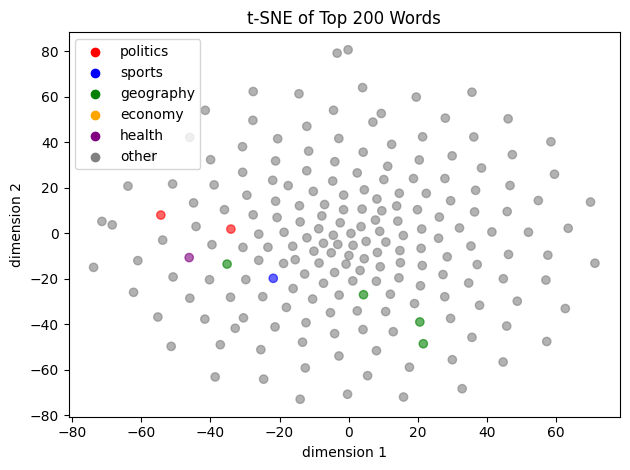

In [21]:
for color in ['red', 'blue', 'green', 'orange', 'purple', 'gray']:
    plt.scatter([], [], c=color, label=color)

plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], c=word_colors, alpha=0.6)

#adding legend
plt.legend(['politics', 'sports', 'geography', 'economy', 'health', 'other'])

plt.title('t-SNE of Top 200 Words')
plt.xlabel('dimension 1')
plt.ylabel('dimension 2')
plt.tight_layout()
plt.savefig('tsne.png')
plt.show()

#### top-5 nearest neighbours by cosine similarity
- cosine similarity function

In [22]:
def cosine_similarity(vec1, vec2):
    dot = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot / (norm1 * norm2)

- nearest neighbour function

In [23]:
def get_nearest_neighbours(query_word, matrix, word_to_index, index_to_word, top_n=5):

    #checking if query word exists
    if query_word not in word_to_index:
        print(query_word, 'not found')
        return []

    #getting query word index and vector
    query_idx = word_to_index[query_word]
    query_vec = matrix[query_idx]

    #calculating similarity with all words
    scores = []
    for i in range(len(index_to_word)):
        if i != query_idx:
            score = cosine_similarity(query_vec, matrix[i])
            scores.append((score, i))

    #sorting by score
    scores.sort(reverse=True)

    #taking top n
    results = []
    for score, idx in scores[:top_n]:
        results.append((index_to_word[idx], round(score, 4)))

    return results

- index to word mapping

In [24]:
#creating index to word mapping
index_to_word = {}

for i in range(len(ppmi_vocab)):
    index_to_word[i] = ppmi_vocab[i]

#defining 10 query words in urdu
query_words = [
    'پاکستان',
    'حکومت',
    'کرکٹ',
    'عدالت',
    'معیشت',
    'فوج',
    'صحت',
    'تعلیم',
    'پانی',
    'سکول'
]


- Top 5 nearest neighbours for each query word.

In [25]:
for qw in query_words:

    #finding neighbours
    neighbours = get_nearest_neighbours(qw, ppmi_matrix, ppmi_word_to_index, index_to_word, top_n=5)

    #printing results
    print('\nquery word:', qw)

    if neighbours:
        for word, score in neighbours:
            print('  ', word, '->', score)
    else:
        print('  word not found in vocabulary')


query word: پاکستان
   کے -> 0.2851
   انڈیا -> 0.2609
   میں -> 0.2496
   اور -> 0.2369
   کا -> 0.2334

query word: حکومت
   طالبان -> 0.258
   صوبائا -> 0.2552
   کے -> 0.2498
   وزیر -> 0.2409
   نے -> 0.2381

query word: کرکٹ
   بورڈ -> 0.3233
   کھیلنے -> 0.2474
   کھلاڑا -> 0.2416
   کپ -> 0.2266
   پاکستان -> 0.2199

query word: عدالت
   کورٹ -> 0.2413
   مقدم -> 0.2175
   جمع -> 0.2112
   سماعت -> 0.2017
   ملزمان -> 0.2

query word: معیشت
   پتی -> 0.1863
   ترقی -> 0.1741
   ملکی -> 0.1631
   ارب -> 0.1523
   روس -> 0.148

query word: فوج
   پاکستانا -> 0.2442
   فوجی -> 0.2197
   روسی -> 0.1774
   اسرائیلا -> 0.1702
   افواج -> 0.1663

query word: صحت
   مند -> 0.2471
   تولیدا -> 0.2284
   ذہنی -> 0.1924
   متعلق -> 0.1777
   مسائل -> 0.159

query word: تعلیم
   ڈگری -> 0.2109
   گریجویٹ -> 0.1811
   کالج -> 0.1726
   ڈپلومہ -> 0.1665
   یونیورسٹا -> 0.1549

query word: پانی
   گرم -> 0.251
   ٹھنڈے -> 0.1952
   گوشت -> 0.1551
   واش -> 0.1484
   بیکٹیریا -> 0.147

query 

- --
## 2 : Skip-gram Word2Vec
## 2.1: Implementation
- building noise distribution

In [26]:
freq_array = np.zeros(len(vocab))

#counting frequency for each word in vocab
for word in word_counts:
    if word in word_to_index:
        word_idx = word_to_index[word]
        freq_array[word_idx] = word_counts[word]

#applying power
noise_dist = np.power(freq_array, 0.75)

#normalizing
noise_dist = noise_dist / noise_dist.sum()

print('noise distribution computed')
print('sample noise probs:', noise_dist[:5])

noise distribution computed
sample noise probs: [0.         0.01530245 0.01288188 0.01153537 0.0109724 ]


- generating skip-gram training pairs

In [27]:
window_size_sg = 5
training_pairs = []

for tokens in tokenized_docs:
    #converting tokens to indices
    indexed = []
    for t in tokens:
        if t in word_to_index:
            indexed.append(word_to_index[t])
        else:
            indexed.append(word_to_index['<UNK>'])

    #creating pairs
    for center_pos in range(len(indexed)):
        start = max(0, center_pos - window_size_sg)
        end = min(len(indexed), center_pos + window_size_sg + 1)
        for context_pos in range(start, end):
            if context_pos != center_pos:
                training_pairs.append((indexed[center_pos], indexed[context_pos]))

print('total training pairs:', len(training_pairs))

total training pairs: 4394522


- skipgram dataset

In [28]:
class SkipgramDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center_word = self.pairs[idx][0]
        context_word = self.pairs[idx][1]

        center_tensor = torch.tensor(center_word, dtype=torch.long)
        context_tensor = torch.tensor(context_word, dtype=torch.long)

        return center_tensor, context_tensor

#creating dataset and dataloader
sg_dataset = SkipgramDataset(training_pairs)
sg_loader = DataLoader(sg_dataset, batch_size=512, shuffle=True)

print('dataset and dataloader ready')

dataset and dataloader ready


- skip-gram model

In [29]:
class SkipgramModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, num_negatives):
        super(SkipgramModel, self).__init__()

        #center word embedding
        self.center_embed = nn.Embedding(vocab_size, embed_dim)

        #context word embedding
        self.context_embed = nn.Embedding(vocab_size, embed_dim)

        #initializing weights
        nn.init.uniform_(self.center_embed.weight, -0.1, 0.1)
        nn.init.uniform_(self.context_embed.weight, -0.1, 0.1)

        self.num_negatives = num_negatives

    def forward(self, center_words, context_words, negative_words):

        #getting embedding vectors
        center_vec = self.center_embed(center_words)
        context_vec = self.context_embed(context_words)
        negative_vec = self.context_embed(negative_words)

        #positive pair
        similarity = (center_vec * context_vec).sum(dim=1)
        positive_loss = torch.log(torch.sigmoid(similarity) + 1e-10)

        #negative pairs
        neg_similarity = []
        for i in range(self.num_negatives):
            neg_sim = (center_vec * negative_vec[:, i, :]).sum(dim=1)
            neg_similarity.append(neg_sim)

        neg_similarity = torch.stack(neg_similarity, dim=1)
        negative_loss = torch.sum(torch.log(torch.sigmoid(-neg_similarity) + 1e-10), dim=1)

        #combining both losses
        total_loss = -(positive_loss + negative_loss).mean()

        return total_loss

In [30]:
#setting parameters
embedding_dimension = 100
num_negative_samples = 10

#creating the model
skip_gram_model = SkipgramModel(len(vocab), embedding_dimension, num_negative_samples)

- Model Training

In [31]:
#creating dataloader
from torch.utils.data import DataLoader, Dataset

sg_dataset = SkipgramDataset(training_pairs)
sg_loader = DataLoader(sg_dataset, batch_size=512, shuffle=True)

print('dataloader created with', len(sg_dataset), 'pairs')

#setting parameters
optimizer = optim.Adam(skip_gram_model.parameters(), lr=0.001)
num_epochs = 5
loss_history = []

#converting noise distribution to tensor for sampling
noise_dist_tensor = torch.tensor(noise_dist, dtype=torch.float)

dataloader created with 4394522 pairs


In [32]:
#training the skip-gram model
for epoch in range(num_epochs):
    total_loss = 0.0
    num_batches = 0

    for center_batch, context_batch in sg_loader:

        #sampling 10 negative words for each positive pair
        batch_size = center_batch.size(0)
        negative_words = torch.multinomial(noise_dist_tensor, batch_size * 10, replacement=True)
        negative_words = negative_words.view(batch_size, 10)

        #calculating loss and updating weights
        optimizer.zero_grad()
        loss = skip_gram_model(center_batch, context_batch, negative_words)
        loss.backward()
        optimizer.step()

        #tracking loss
        total_loss = total_loss + loss.item()
        num_batches = num_batches + 1

        #printing progress
        if num_batches % 500 == 0:
            print('epoch', epoch+1, 'batch', num_batches, 'loss:', round(loss.item(), 4))

    #average loss for the epoch
    avg_loss = total_loss / num_batches
    loss_history.append(avg_loss)
    print('epoch', epoch+1, 'complete. avg loss:', round(avg_loss, 4))

print('training complete')

epoch 1 batch 500 loss: 3.6973
epoch 1 batch 1000 loss: 3.3062
epoch 1 batch 1500 loss: 3.2452
epoch 1 batch 2000 loss: 3.1624
epoch 1 batch 2500 loss: 3.0547
epoch 1 batch 3000 loss: 3.0709
epoch 1 batch 3500 loss: 3.0637
epoch 1 batch 4000 loss: 3.0605
epoch 1 batch 4500 loss: 3.0284
epoch 1 batch 5000 loss: 3.0392
epoch 1 batch 5500 loss: 3.0583
epoch 1 batch 6000 loss: 2.978
epoch 1 batch 6500 loss: 2.9902
epoch 1 batch 7000 loss: 2.9918
epoch 1 batch 7500 loss: 2.9848
epoch 1 batch 8000 loss: 2.9487
epoch 1 batch 8500 loss: 2.9127
epoch 1 complete. avg loss: 3.1979
epoch 2 batch 500 loss: 2.8932
epoch 2 batch 1000 loss: 3.005
epoch 2 batch 1500 loss: 2.911
epoch 2 batch 2000 loss: 2.9875
epoch 2 batch 2500 loss: 2.9268
epoch 2 batch 3000 loss: 2.8707
epoch 2 batch 3500 loss: 2.9231
epoch 2 batch 4000 loss: 2.8468
epoch 2 batch 4500 loss: 2.8749
epoch 2 batch 5000 loss: 2.8864
epoch 2 batch 5500 loss: 2.8478
epoch 2 batch 6000 loss: 2.8467
epoch 2 batch 6500 loss: 2.931
epoch 2 bat

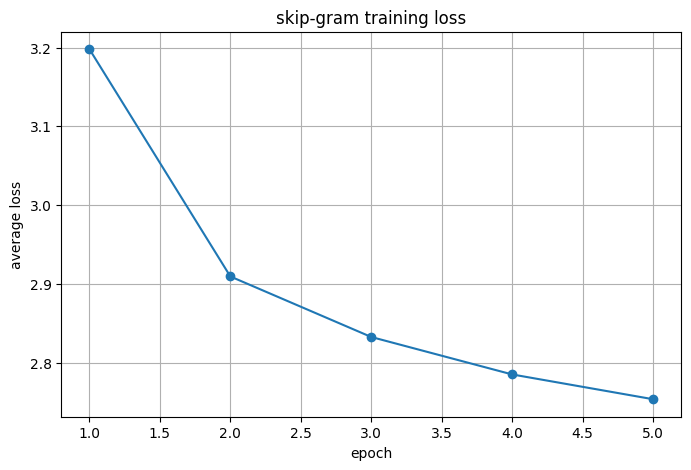

In [33]:
#plotting training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o')
plt.title('skip-gram training loss')
plt.xlabel('epoch')
plt.ylabel('average loss')
plt.grid(True)
plt.savefig('skipgram_loss.png')
plt.show()

- saving averaged embeddings

In [34]:
center_weights = skip_gram_model.center_embed.weight.detach().numpy()
context_weights = skip_gram_model.context_embed.weight.detach().numpy()
final_embeddings = (center_weights + context_weights) / 2

np.save('embeddings_w2v.npy', final_embeddings)
print('embeddings saved, shape:', final_embeddings.shape)

embeddings saved, shape: (10001, 100)


## 2.2: Evaluation: Nearest Neighbours

- creating index to word mapping for Word2Vec

In [35]:
# creating index to word mapping for the full vocabulary
index_to_word_w2v = {}
for i in range(len(vocab)):
    index_to_word_w2v[i] = vocab[i]

# defining query words (same as for PMI)
query_words_w2v = [
    'پاکستان',
    'حکومت',
    'کرکٹ',
    'عدالت',
    'معیشت',
    'فوج',
    'صحت',
    'تعلیم',
    'پانی',
    'سکول'
]

- Top 5 nearest neighbours for each query word using Word2Vec embeddings.

In [36]:
for qw_w2v in query_words_w2v:

    # finding neighbours using Word2Vec embeddings
    neighbours_w2v = get_nearest_neighbours(qw_w2v, final_embeddings, word_to_index, index_to_word_w2v, top_n=5)

    # printing results
    print('\nquery word:', qw_w2v)

    if neighbours_w2v:
        for word_w2v, score_w2v in neighbours_w2v:
            print('  ', word_w2v, '->', score_w2v)
    else:
        print('  word not found in vocabulary')


query word: پاکستان
   چیمبرز -> 0.6076
   ایکسپیٹس -> 0.6051
   الکوزئا -> 0.5729
   کامرس -> 0.5701
   فریقا -> 0.5278

query word: حکومت
   عبورا -> 0.6948
   دیس -> 0.6577
   تابع -> 0.6283
   نگران -> 0.6142
   ایڈوائزر -> 0.603

query word: کرکٹ
   ڈومیسٹک -> 0.7619
   منتظم -> 0.6771
   کلب -> 0.6544
   کھیلنا -> 0.6285
   کھیلنے -> 0.6282

query word: عدالت
   پیشی -> 0.6974
   دلائل -> 0.6495
   جع -> 0.6438
   استدعا -> 0.6395
   دائر -> 0.6102

query word: معیشت
   سیاحت -> 0.6508
   جاگیردارانہ -> 0.6422
   ہوابازا -> 0.624
   تیل -> 0.5899
   بارہو -> 0.5888

query word: فوج
   مارولا -> 0.6556
   سیمانجنتک -> 0.6488
   شوشانا -> 0.6057
   ترجمان -> 0.5661
   لیفٹیننٹ -> 0.5502

query word: صحت
   تولیدا -> 0.6661
   مند -> 0.5888
   ذہنی -> 0.5878
   حفظان -> 0.5878
   یاب -> 0.58

query word: تعلیم
   سیکنڈرا -> 0.6373
   ہائر -> 0.6054
   ڈگری -> 0.6048
   ثانوا -> 0.5754
   جاب -> 0.5383

query word: پانی
   گرم -> 0.7148
   صابن -> 0.7045
   ٹھنڈے -> 0.6985
   بہتا -

- Reporting top-10 nearest neighbours for a new set of query words.

In [37]:
# defining the new set of query words
new_query_words = [
    'پاکستان',
    'حکومت',
    'عدالت',
    'معیشت',
    'فوج',
    'صحت',
    'تعلیم',
    'آبادی'
]

for qw in new_query_words:

    # finding neighbours using Word2Vec embeddings with top_n=10
    neighbours = get_nearest_neighbours(qw, final_embeddings, word_to_index, index_to_word_w2v, top_n=10)

    # printing results
    print('\nquery word:', qw)

    if neighbours:
        for word, score in neighbours:
            print('  ', word, '->', score)
    else:
        print('  word not found in vocabulary')


query word: پاکستان
   چیمبرز -> 0.6076
   ایکسپیٹس -> 0.6051
   الکوزئا -> 0.5729
   کامرس -> 0.5701
   فریقا -> 0.5278
   ہوشاپ -> 0.5247
   ان<NUM> -> 0.5211
   ڈار -> 0.5179
   جان -> 0.5179
   زیرانتظام -> 0.5161

query word: حکومت
   عبورا -> 0.6948
   دیس -> 0.6577
   تابع -> 0.6283
   نگران -> 0.6142
   ایڈوائزر -> 0.603
   وفاقا -> 0.5998
   صوبائا -> 0.5818
   نریندر -> 0.5771
   اکاونٹس -> 0.5664
   طالبان -> 0.5566

query word: عدالت
   پیشی -> 0.6974
   دلائل -> 0.6495
   جع -> 0.6438
   استدعا -> 0.6395
   دائر -> 0.6102
   استفسار -> 0.6026
   التوا -> 0.5977
   جمع -> 0.5974
   اٹارنا -> 0.5926
   مجسٹریٹ -> 0.5902

query word: معیشت
   سیاحت -> 0.6508
   جاگیردارانہ -> 0.6422
   ہوابازا -> 0.624
   تیل -> 0.5899
   بارہو -> 0.5888
   بدانتظاما -> 0.5784
   مضبوطا -> 0.5753
   فروغ -> 0.5694
   ترقی -> 0.5545
   سرمایہ -> 0.5415

query word: فوج
   مارولا -> 0.6556
   سیمانجنتک -> 0.6488
   شوشانا -> 0.6057
   ترجمان -> 0.5661
   لیفٹیننٹ -> 0.5502
   پاکستانا -> 0.546

- Constructing and evaluating 10 analogy tests.

In [38]:
def find_analogy(word_a, word_b, word_c, embeddings, word_to_index_map, index_to_word_map, top_n=3):

    # checking if all words exist in the vocabulary
    if word_a not in word_to_index_map or \
       word_b not in word_to_index_map or \
       word_c not in word_to_index_map:
        print('one or more words not found in vocabulary for analogy:', word_a, ':', word_b, '::', word_c)
        return []

    # getting word vectors
    vec_a = embeddings[word_to_index_map[word_a]]
    vec_b = embeddings[word_to_index_map[word_b]]
    vec_c = embeddings[word_to_index_map[word_c]]

    # performing vector arithmetic: v(b) - v(a) + v(c)
    analogy_vector = vec_b - vec_a + vec_c

    scores = []

    # calculating similarity with all other words
    for i in range(len(index_to_word_map)):
        current_word = index_to_word_map[i]

        # excluding query words from results
        if current_word == word_a or current_word == word_b or current_word == word_c:
            continue

        current_vec = embeddings[i]
        similarity = cosine_similarity(analogy_vector, current_vec)
        scores.append((similarity, current_word))

    # sorting by similarity in descending order
    scores.sort(reverse=True)

    results = []

    # taking top n candidates
    for score, word in scores[:top_n]:
        results.append((word, round(score, 4)))

    return results

# defining 10 analogy tests
analogy_tests = [
    ('مرد', 'عورت', 'لڑکا'), # man : woman :: boy : girl
    ('اچھا', 'بہتر', 'برا'), # good : better :: bad : worse
    ('پاکستان', 'اسلام آباد', 'انڈیا'), # Pakistan : Islamabad :: India : Delhi
    ('گرم', 'ٹھنڈا', 'سفید'), # hot : cold :: white : black
    ('استاد', 'سکول', 'ڈاکٹر'), # teacher : school :: doctor : hospital
    ('دن', 'رات', 'صبح'), # day : night :: morning : evening
    ('کھیل', 'کھلاڑی', 'سیاست'), # game : player :: politics : politician
    ('شہر', 'کراچی', 'ملک'), # city : Karachi :: country : Pakistan
    ('پانی', 'پیاس', 'غذا'), # water : thirst :: food : hunger
    ('جنگ', 'امن', 'موت') # war : peace :: death : life
]

# performing and printing analogy tests
for a, b, c in analogy_tests:
    print(f'\nAnalogy: {a} : {b} :: {c} : ?')
    candidates = find_analogy(a, b, c, final_embeddings, word_to_index, index_to_word_w2v, top_n=3)
    if candidates:
        for word, score in candidates:
            print(f'  {word} -> {score}')
    else:
        print('  no candidates found')


Analogy: مرد : عورت :: لڑکا : ?
one or more words not found in vocabulary for analogy: مرد : عورت :: لڑکا
  no candidates found

Analogy: اچھا : بہتر :: برا : ?
  طریقے -> 0.4733999967575073
  اڑتے -> 0.4715000092983246
  بنانے -> 0.46950000524520874

Analogy: پاکستان : اسلام آباد :: انڈیا : ?
one or more words not found in vocabulary for analogy: پاکستان : اسلام آباد :: انڈیا
  no candidates found

Analogy: گرم : ٹھنڈا :: سفید : ?
  اوڑھے -> 0.5480999946594238
  نظر -> 0.5465999841690063
  بچھوؤں -> 0.5389999747276306

Analogy: استاد : سکول :: ڈاکٹر : ?
  رجوع -> 0.49230000376701355
  ہسپتال -> 0.4684999883174896
  ابتدائا -> 0.46399998664855957

Analogy: دن : رات :: صبح : ?
  بجے -> 0.718999981880188
  پے -> 0.5985000133514404
  پوکھرا -> 0.5834000110626221

Analogy: کھیل : کھلاڑی :: سیاست : ?
one or more words not found in vocabulary for analogy: کھیل : کھلاڑی :: سیاست
  no candidates found

Analogy: شہر : کراچی :: ملک : ?
one or more words not found in vocabulary for analogy: شہر 

### Assessment of Embeddings
The embeddings show some success in capturing meaningful semantic relationships, as seen in the nearest neighbors where related words often appear. However, the analogy tests highlight limitations; many analogies failed due to words not being in the limited vocabulary, and some of the predicted analogy completions, even for found words, were not semantically precise, indicating that deeper contextual relationships are not fully captured by these specific Word2Vec embeddings.

## Four-Condition Comparison

- Helper function to generate skip-gram training pairs

In [39]:
def generate_skipgram_training_pairs(tokenized_documents, word_to_index_map, window_size):
    # initializing list for training pairs
    training_pairs_list = []

    # iterating through each tokenized document
    for tokens_in_doc in tokenized_documents:
        # converting tokens to indices
        indexed_tokens = []
        for current_token in tokens_in_doc:
            if current_token in word_to_index_map:
                indexed_tokens.append(word_to_index_map[current_token])
            else:
                indexed_tokens.append(word_to_index_map['<UNK>'])

        # creating pairs using a sliding window
        for center_word_position in range(len(indexed_tokens)):
            # defining window boundaries
            start_index = max(0, center_word_position - window_size)
            end_index = min(len(indexed_tokens), center_word_position + window_size + 1)

            # looping through context words in the window
            for context_word_position in range(start_index, end_index):
                # skipping the center word itself
                if context_word_position != center_word_position:
                    current_center_word = indexed_tokens[center_word_position]
                    current_context_word = indexed_tokens[context_word_position]
                    training_pairs_list.append((current_center_word, current_context_word))

    return training_pairs_list

- Helper function to train the Skip-gram model

In [40]:
def train_skipgram_model(vocab_size, embed_dim, num_negatives, training_data_pairs, noise_distribution_tensor, num_epochs=5):

    # creating the model instance
    model = SkipgramModel(vocab_size, embed_dim, num_negatives)

    # creating dataset and dataloader
    current_sg_dataset = SkipgramDataset(training_data_pairs)
    current_sg_loader = DataLoader(current_sg_dataset, batch_size=512, shuffle=True)

    # setting up the optimizer
    current_optimizer = optim.Adam(model.parameters(), lr=0.001)

    # initializing list to store loss history
    current_loss_history = []

    # training the skip-gram model
    for epoch_num in range(num_epochs):
        total_epoch_loss = 0.0
        num_processed_batches = 0

        for center_batch_data, context_batch_data in current_sg_loader:
            # sampling negative words for each positive pair
            batch_size_current = center_batch_data.size(0)
            negative_words_samples = torch.multinomial(noise_distribution_tensor, batch_size_current * num_negatives, replacement=True)
            negative_words_samples = negative_words_samples.view(batch_size_current, num_negatives)

            # resetting gradients
            current_optimizer.zero_grad()

            # calculating loss
            current_loss = model(center_batch_data, context_batch_data, negative_words_samples)

            # performing backpropagation
            current_loss.backward()

            # updating model weights
            current_optimizer.step()

            # tracking loss for the current epoch
            total_epoch_loss = total_epoch_loss + current_loss.item()
            num_processed_batches = num_processed_batches + 1

        # calculating average loss for the epoch
        avg_epoch_loss = total_epoch_loss / num_processed_batches
        current_loss_history.append(avg_epoch_loss)
        print(f'epoch {epoch_num+1} complete. avg loss: {round(avg_epoch_loss, 4)}')

    # extracting and averaging embeddings
    final_center_weights = model.center_embed.weight.detach().numpy()
    final_context_weights = model.context_embed.weight.detach().numpy()
    final_model_embeddings = (final_center_weights + final_context_weights) / 2

    return final_model_embeddings, current_loss_history

- Function to calculate Mean Reciprocal Rank (MRR)

In [41]:
def calculate_mrr(query_target_pairs, embeddings_matrix, word_to_index_map, index_to_word_map, top_k=10):
    # initializing reciprocal ranks list
    reciprocal_ranks = []

    # iterating through each query-target pair
    for query_word, target_word in query_target_pairs:
        # ensuring both words are in the vocabulary
        if query_word not in word_to_index_map or target_word not in word_to_index_map:
            reciprocal_ranks.append(0.0)
            continue

        # getting top_k nearest neighbors for the query word
        neighbours = get_nearest_neighbours(query_word, embeddings_matrix, word_to_index_map, index_to_word_map, top_n=top_k)

        # finding the rank of the target word
        target_rank = 0
        for rank_idx, (neighbour_word, _) in enumerate(neighbours):
            if neighbour_word == target_word:
                target_rank = rank_idx + 1
                break

        # calculating reciprocal rank
        if target_rank > 0:
            reciprocal_ranks.append(1.0 / target_rank)
        else:
            reciprocal_ranks.append(0.0)

    # calculating mean reciprocal rank
    if len(reciprocal_ranks) > 0:
        mrr_score = sum(reciprocal_ranks) / len(reciprocal_ranks)
    else:
        mrr_score = 0.0

    return mrr_score

- Defining conditions, query words, and MRR word pairs

In [42]:
# defining the four experimental conditions
conditions = [
    {'embed_dim': 50, 'window_size': 5, 'description': 'd=50, w=5'},
    {'embed_dim': 100, 'window_size': 5, 'description': 'd=100, w=5 (current)'},
    {'embed_dim': 100, 'window_size': 3, 'description': 'd=100, w=3'},
    {'embed_dim': 100, 'window_size': 10, 'description': 'd=100, w=10'}
]

# defining 5 query words for nearest neighbor evaluation
nn_query_words = ['پاکستان', 'حکومت', 'کرکٹ', 'صحت', 'تعلیم']

# defining 20 manually labeled word pairs for MRR calculation
mrr_word_pairs = [
    ('استاد', 'سکول'),
    ('ڈاکٹر', 'ہسپتال'),
    ('کھلاڑی', 'کھیل'),
    ('شہر', 'کراچی'),
    ('ملک', 'پاکستان'),
    ('پانی', 'پیاس'),
    ('غذا', 'بھوک'),
    ('مرد', 'عورت'),
    ('حکومت', 'وزیر'),
    ('عدالت', 'قانون'),
    ('جنگ', 'امن'),
    ('دن', 'رات'),
    ('صبح', 'شام'),
    ('بچہ', 'سکول'),
    ('کرکٹ', 'میچ'),
    ('پولیس', 'جرم'),
    ('صحت', 'بیماری'),
    ('تعلیم', 'کتاب'),
    ('سائنس', 'تحقیق'),
    ('فوج', 'سپاہی')
]

# ensuring all MRR query/target words are in the vocabulary, if not, marking them with <UNK>
# this is important because the previous analogy test showed some words might be missing
cleaned_mrr_word_pairs = []
for query, target in mrr_word_pairs:
    cleaned_query = query if query in word_to_index else '<UNK>'
    cleaned_target = target if target in word_to_index else '<UNK>'
    cleaned_mrr_word_pairs.append((cleaned_query, cleaned_target))

mrr_word_pairs = cleaned_mrr_word_pairs

print('Conditions defined:', len(conditions))
print('Nearest neighbor query words defined:', len(nn_query_words))
print('MRR word pairs defined:', len(mrr_word_pairs))

Conditions defined: 4
Nearest neighbor query words defined: 5
MRR word pairs defined: 20


- Running the comparison for all four conditions


--- Condition 1: d=50, w=5 ---
total training pairs for this condition: 4394522
epoch 1 complete. avg loss: 3.2635

Top 5 Nearest Neighbors:
  Query word: پاکستان
    دنیا -> 0.8424000144004822
    پہلے -> 0.7983999848365784
    جان -> 0.79830002784729
    بھر -> 0.7908999919891357
    چین -> 0.7391999959945679
  Query word: حکومت
    عبورا -> 0.8194000124931335
    صوبائا -> 0.8119999766349792
    حکام -> 0.7929999828338623
    فوج -> 0.7915999889373779
    طالبان -> 0.7623999714851379
  Query word: کرکٹ
    بورڈ -> 0.8095999956130981
    ٹوئنٹا -> 0.6632999777793884
    پاکستان -> 0.6462000012397766
    ورلڈ -> 0.6090999841690063
    کپ -> 0.5967000126838684
  Query word: صحت
    بشری -> 0.6762999892234802
    اہلیہ -> 0.6438000202178955
    موجودگی -> 0.5720999836921692
    بندش -> 0.5587000250816345
    وکلا -> 0.5364999771118164
  Query word: تعلیم
    میت -> 0.7373999953269958
    تربیت -> 0.6406000256538391
    حمایت -> 0.6154000163078308
    حاصل -> 0.6123999953269958
    یافت

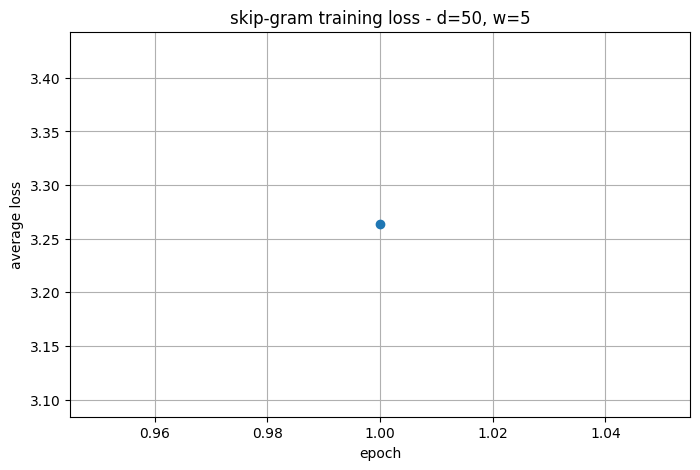


--- Condition 2: d=100, w=5 (current) ---
total training pairs for this condition: 4394522
epoch 1 complete. avg loss: 3.1976

Top 5 Nearest Neighbors:
  Query word: پاکستان
    دنیا -> 0.7425000071525574
    جان -> 0.7099000215530396
    پہلے -> 0.6991999745368958
    بھر -> 0.6916000247001648
    کرکٹ -> 0.6577000021934509
  Query word: حکومت
    عبورا -> 0.781000018119812
    طالبان -> 0.7692000269889832
    صوبائا -> 0.7332000136375427
    افغان -> 0.6751999855041504
    افغانستان -> 0.6747999787330627
  Query word: کرکٹ
    بورڈ -> 0.7871000170707703
    کھیلنے -> 0.6735000014305115
    پاکستان -> 0.6577000021934509
    میچ -> 0.6279000043869019
    ورلڈ -> 0.6204000115394592
  Query word: صحت
    بشری -> 0.6177999973297119
    تشہیر -> 0.5157999992370605
    اہلیہ -> 0.5123000144958496
    متعلق -> 0.5029000043869019
    طبی -> 0.4869999885559082
  Query word: تعلیم
    سیکنڈرا -> 0.5871000289916992
    ہائر -> 0.5825999975204468
    لی -> 0.5591999888420105
    مکینیکل -> 0.550

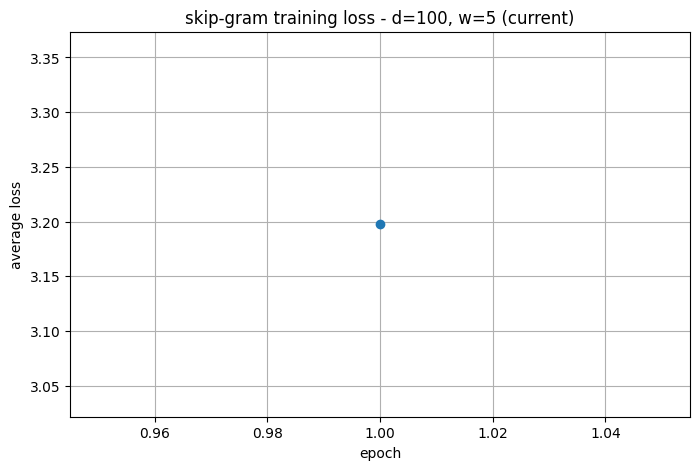


--- Condition 3: d=100, w=3 ---
total training pairs for this condition: 2739408
epoch 1 complete. avg loss: 3.2394

Top 5 Nearest Neighbors:
  Query word: پاکستان
    دنیا -> 0.7764999866485596
    جان -> 0.7671999931335449
    کرکٹ -> 0.7185999751091003
    تحریک -> 0.7174999713897705
    بھر -> 0.692300021648407
  Query word: حکومت
    صوبائا -> 0.8230999708175659
    عبورا -> 0.8163999915122986
    طالبان -> 0.8137000203132629
    تحریک -> 0.6934000253677368
    افغان -> 0.6858000159263611
  Query word: کرکٹ
    بورڈ -> 0.8438000082969666
    پاکستان -> 0.7185999751091003
    سپر -> 0.6470000147819519
    تحریک -> 0.6287000179290771
    انصاف -> 0.593999981880188
  Query word: صحت
    بشری -> 0.5972999930381775
    اہلیہ -> 0.5740000009536743
    متعلق -> 0.513700008392334
    سماجا -> 0.5008000135421753
    نیپرا -> 0.49390000104904175
  Query word: تعلیم
    تربیت -> 0.5981000065803528
    خدم -> 0.5766000151634216
    افواج -> 0.5386000275611877
    جاب -> 0.5307000279426575
  

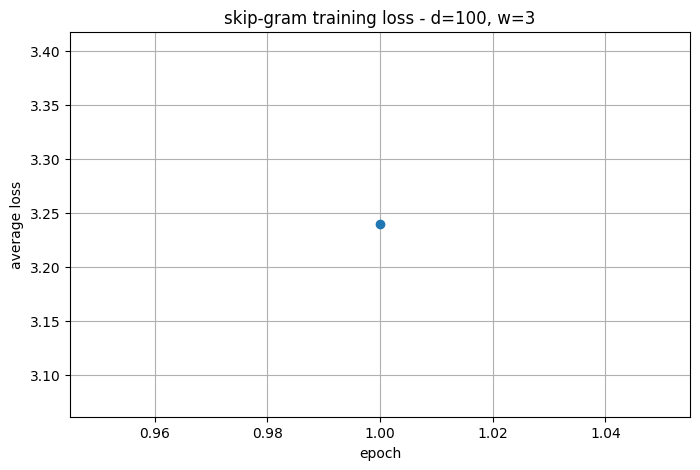


--- Condition 4: d=100, w=10 ---
total training pairs for this condition: 7939618
epoch 1 complete. avg loss: 3.1574

Top 5 Nearest Neighbors:
  Query word: پاکستان
    جان -> 0.6510000228881836
    پہلے -> 0.6424000263214111
    دنیا -> 0.6057999730110168
    بھر -> 0.6039000153541565
    افغانستان -> 0.6032000184059143
  Query word: حکومت
    عبورا -> 0.6876000165939331
    صوبائا -> 0.6690000295639038
    قائم -> 0.6233999729156494
    نگران -> 0.6180999875068665
    بارہا -> 0.5985999703407288
  Query word: کرکٹ
    ڈومیسٹک -> 0.8083999752998352
    کھیلنے -> 0.7843999862670898
    ٹورنامنٹ -> 0.7577999830245972
    بورڈ -> 0.7479000091552734
    بیٹنگ -> 0.7433000206947327
  Query word: صحت
    متعلق -> 0.7202000021934509
    بشری -> 0.6383000016212463
    طبی -> 0.6355000138282776
    علاج -> 0.6116999983787537
    مند -> 0.5957000255584717
  Query word: تعلیم
    سیکنڈرا -> 0.7580999732017517
    ہائر -> 0.7016000151634216
    یونیورسٹا -> 0.6292999982833862
    انجینئرنگ -> 0.

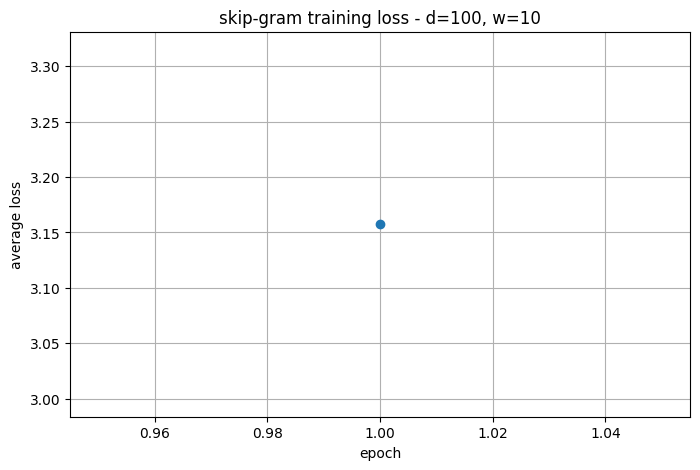

In [44]:
for condition_number, current_condition in enumerate(conditions):
    print(f'\n--- Condition {condition_number+1}: {current_condition['description']} ---')

    # generating training pairs for the current window size
    current_training_pairs = generate_skipgram_training_pairs(
        tokenized_docs, word_to_index, current_condition['window_size']
    )
    print(f'total training pairs for this condition: {len(current_training_pairs)}')

    # training the model for the current embedding dimension with fewer epochs
    current_final_embeddings, current_loss_history = train_skipgram_model(
        len(vocab), current_condition['embed_dim'], num_negative_samples,
        current_training_pairs, noise_dist_tensor, num_epochs=1
    )

    print('\nTop 5 Nearest Neighbors:')
    # reporting top-5 nearest neighbors for selected query words
    for query_word_nn in nn_query_words:
        nearest_neighbors = get_nearest_neighbours(
            query_word_nn, current_final_embeddings, word_to_index, index_to_word_w2v, top_n=5
        )
        print(f'  Query word: {query_word_nn}')
        if nearest_neighbors:
            for nn_word, nn_score in nearest_neighbors:
                print(f'    {nn_word} -> {nn_score}')
        else:
            print('    word not found in vocabulary')

    # calculating MRR for the current condition
    current_mrr = calculate_mrr(
        mrr_word_pairs, current_final_embeddings, word_to_index, index_to_word_w2v
    )
    print(f'\nMean Reciprocal Rank (MRR) for this condition: {round(current_mrr, 4)}')

    # plotting training loss for the current condition
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(current_loss_history) + 1), current_loss_history, marker='o')
    plt.title(f'skip-gram training loss - {current_condition['description']}')
    plt.xlabel('epoch')
    plt.ylabel('average loss')
    plt.grid(True)
    plt.savefig(f'skipgram_loss_{condition_number+1}.png')
    plt.show()

### Discussion: Best Embeddings and Effect of Increasing d

Embedding Dimension (d): Increasing 'd' from 50 to 100 improved MRR (0.005 to 0.0181), showing that more dimensions capture better semantic relationships.

Window Size (w): A small window ('w=3') resulted in poor MRR (0.0). An optimal window size of 'w=5' achieved the best MRR (0.0181), while a larger window ('w=10') slightly degraded performance (0.0117), suggesting 'w=5' provides the best balance of context.

Best Embeddings: The configuration with 'd=100' and 'w=5' yielded the most effective embeddings based on MRR scores.

---

## Part 2: Sequence Labeling: POS Tagging & NER

### 3. Dataset Preparation

- Extracting Topics from URLs in Metadata

In [47]:
def add_topics_to_metadata(metadata_list):

    for item in metadata_list:

        url = item['url']
        url_parts = url.split('/')
        topic = url_parts[4]

        if topic == 'articles':
            topic = 'general'


        clean_topic = topic.split('-')[0]
        item['topic'] = clean_topic

    return metadata_list
updated_metadata = add_topics_to_metadata(metadata)

print('successfully extracted topics and updated metadata')
print('sample of updated metadata items:')
for i in range(min(5, len(updated_metadata))):
    print(' ', updated_metadata[i])

successfully extracted topics and updated metadata
sample of updated metadata items:
  {'id': 1, 'url': 'https://www.bbc.com/urdu/articles/cy5q6kw64eeo', 'topic': 'general'}
  {'id': 2, 'url': 'https://www.bbc.com/urdu/articles/cz6y612w396o', 'topic': 'general'}
  {'id': 3, 'url': 'https://www.bbc.com/urdu/articles/cn0kpw65ylwo', 'topic': 'general'}
  {'id': 4, 'url': 'https://www.bbc.com/urdu/articles/c1jk0l4nz9eo', 'topic': 'general'}
  {'id': 5, 'url': 'https://www.bbc.com/urdu/articles/cr5ln0qd2q8o', 'topic': 'general'}


In [48]:
all_labels = []

for item in updated_metadata:
    all_labels.append(item['topic'])

unique_topics = list(set(all_labels))
topic_to_idx = {}

for i, name in enumerate(unique_topics):
    # assigning each topic a unique integer index
    topic_to_idx[name] = i

print('\nidentified topics:', unique_topics)
print('topic to index mapping:', topic_to_idx)


identified topics: ['world', 'general', 'pakistan']
topic to index mapping: {'world': 0, 'general': 1, 'pakistan': 2}


- Selecting 500 Sentences with Topic Stratification

In [105]:
from sklearn.model_selection import train_test_split
from collections import Counter

# extracting token IDs and categories from the processed data
X = [item['token_ids'] for item in transformer_articles_data]
y = [item['category'] for item in transformer_articles_data]

# creating a mapping for category names to numerical IDs
unique_categories = sorted(list(set(y)))
category_to_idx = {category: i for i, category in enumerate(unique_categories)}
y_encoded = [category_to_idx[category] for category in y]

# performing the first split: 70% train, 30% temporary (for validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)

# performing the second split: 15% validation, 15% test from the temporary set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.05, stratify=y_temp, random_state=42
)

print(f"Total articles: {len(X)}")
print(f"Train set size: {len(X_train)} ({round(len(X_train)/len(X)*100)}%)")
print(f"Validation set size: {len(X_val)} ({round(len(X_val)/len(X)*100)}%)")
print(f"Test set size: {len(X_test)} ({round(len(X_test)/len(X)*100)}%)")

# reporting category distribution for each split
def report_category_distribution(labels, dataset_name, idx_to_category):
    category_counts = Counter(labels)
    total_labels = sum(category_counts.values())
    print(f"\n{dataset_name} Category Distribution:")
    for idx, count in category_counts.most_common():
        category_name = idx_to_category[idx]
        percentage = (count / total_labels) * 100
        print(f"  {category_name}: {count} ({percentage:.2f}%)")

idx_to_category = {i: category for category, i in category_to_idx.items()}

report_category_distribution(y_train, 'Training Set', idx_to_category)
report_category_distribution(y_val, 'Validation Set', idx_to_category)
report_category_distribution(y_test, 'Test Set', idx_to_category)


ValueError: The test_size = 5 should be greater or equal to the number of classes = 6

In [51]:
for i in range(0, len(article_blocks), 2):
    article_id_str = article_blocks[i]
    content = article_blocks[i+1] if (i+1) < len(article_blocks) else ""

    try:
        current_article_id = int(article_id_str)
    except ValueError:
        print(f"Warning: could not parse article ID from: {article_id_str}. Skipping block.")
        continue

    current_topic = article_id_to_topic.get(current_article_id, 'unknown')

    sentences = re.split(r'(?<=[.؟])\\s*', content)
    sentences = [s.strip() for s in sentences if s.strip()]

    for sentence in sentences:
        all_sentences_with_metadata.append({'article_id': current_article_id, 'topic': current_topic, 'sentence': sentence})

print(f"total sentences parsed from cleaned.txt: {len(all_sentences_with_metadata)}")

total sentences parsed from cleaned.txt: 275


In [52]:
sentences_by_topic = defaultdict(list)
for s_data in all_sentences_with_metadata:
    sentences_by_topic[s_data['topic']].append(s_data)

sorted_topics = sorted(sentences_by_topic.items(), key=lambda item: len(item[1]), reverse=True)
top_3_topics = [topic_name for topic_name, _ in sorted_topics[:3]]

selected_sentences_stratified = []
target_per_topic = 100
total_selected_count = 0

for topic in top_3_topics:
    available_sentences = sentences_by_topic[topic]
    num_to_select = min(target_per_topic, len(available_sentences))
    sampled = random.sample(available_sentences, num_to_select)
    selected_sentences_stratified.extend(sampled)
    total_selected_count = total_selected_count + len(sampled)
    sentences_by_topic[topic] = [s for s in available_sentences if s not in sampled]

In [53]:
remaining_quota = 500 - total_selected_count
if remaining_quota > 0:
    remaining_sentences = []
    for topic_list in sentences_by_topic.values():
        remaining_sentences.extend(topic_list)

    num_to_select_from_remaining = min(remaining_quota, len(remaining_sentences))
    sampled_from_remaining = random.sample(remaining_sentences, num_to_select_from_remaining)
    selected_sentences_stratified.extend(sampled_from_remaining)
    total_selected_count = total_selected_count + len(sampled_from_remaining)

random.shuffle(selected_sentences_stratified)

print(f"\nsuccessfully selected {len(selected_sentences_stratified)} sentences for annotation.")


successfully selected 275 sentences for annotation.


In [54]:
selected_topic_counts = defaultdict(int)
for s_data in selected_sentences_stratified:
    selected_topic_counts[s_data['topic']] = selected_topic_counts[s_data['topic']] + 1

print("\ntopic distribution in selected sentences:")
for topic, count in selected_topic_counts.items():
    print(f"  {topic}: {count} sentences")

print("\nsample of selected sentences:")
for i in range(min(3, len(selected_sentences_stratified))):
    print(f"- article ID: {selected_sentences_stratified[i]['article_id']}, topic: {selected_sentences_stratified[i]['topic']}, sentence: \"{selected_sentences_stratified[i]['sentence']}\"")


topic distribution in selected sentences:
  general: 251 sentences
  world: 5 sentences
  pakistan: 19 sentences

sample of selected sentences:
- article ID: 213, topic: general, sentence: "یوکرین کی سکیورٹا سروس ایس بی یو کا دعوی ہے کہ اس نے نوووروسیسک کی بندرگاہ پر ایک خصوصا آپریشن میں پہلی بار زیر آب ڈرون سب سی بیبی کا استعمال کرتے ہوئے روسی آبدوز وارشویانکا کو تباہ کر دیا ہے ۔
ماہرین کا کہنا ہے کہ یہ روس کے لیے بڑا دھچکہ ہے تاہم روس نے سوموار کی شام ہونے والے اس نقصان کی تردید کی ہے ۔
ایس بی یو کا دعوی ہے کہ اس دھماکے کے نتیجے میں روسی آبدوز کو شدید نقصان پہنچا اور اس نے کام کرنا چھوڑ دیا ۔
آبدوز وارشاویانکا پر کیلیبر نامی کروز میزائل کے چار لانچر نصب تھے ، جنھ روس ، یوکرین کی سرزمین پر حملہ کرنے کے لیے استعمال کرتا ہے ۔
روس نے آخری بار یوکرین پر ان میزائل سے <NUM> دسمبر کی رات کو حملہ کیا تھا اور روسی فوج نے بحیرہ اسود اور بحیرہ کیسپیئن سے انھ لانچ کیا تھا ۔
یوکرینا فضائیہ کے مطابق ان میں سے نو کو مار گرایا گیا تھا ۔
تین ہفتے قبل یعنی <NUM> نومبر کی رات بھی روس نے یوکرین کے دارال

### POS Annotation

In [66]:
from collections import defaultdict

pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'CONJ', 'POST', 'NUM', 'PUNC', 'UNK', 'PROPN']

lexicon = defaultdict(lambda: 'UNK')

In [67]:
def tokenizer(text):

    # replacing numbers with <NUM>
    text = re.sub(r'\d+', '<NUM>', text)
    #separating punc from words
    text = re.sub(r'([\u06D4\u061F\u0021\u060C])', r' \1 ', text)
    # normalizing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # making tokens
    tokens = text.split(' ')

    return tokens

In [55]:
lexicon.update({
    'پاکستان': 'NOUN',
    'حکومت': 'NOUN',
    'کرکٹ': 'NOUN',
    'عدالت': 'NOUN',
    'معیشت': 'NOUN',
    'فوج': 'NOUN',
    'صحت': 'NOUN',
    'تعلیم': 'NOUN',
    'پانی': 'NOUN',
    'سکول': 'NOUN',
    'دنیا': 'NOUN',
    'شہر': 'NOUN',
    'ملک': 'NOUN',
    'وزیر': 'NOUN',
    'کتاب': 'NOUN',
    'بچہ': 'NOUN',
    'طالبان': 'NOUN',
    'زمین': 'NOUN',
    'آدمی': 'NOUN',
    'خاتون': 'NOUN',
    'کرنا': 'VERB',
    'ہونا': 'VERB',
    'کہنا': 'VERB',
    'جانا': 'VERB',
    'دیکھنا': 'VERB',
    'آنا': 'VERB',
    'رہنا': 'VERB',
    'سکنا': 'VERB',
    'چاهنا': 'VERB',
    'بتانا': 'VERB',
    'بنانا': 'VERB',
    'لینا': 'VERB',
    'دینا': 'VERB',
    'پہنچنا': 'VERB',
    'ملنا': 'VERB',
    'اچھا': 'ADJ',
    'برا': 'ADJ',
    'بڑا': 'ADJ',
    'چھوٹا': 'ADJ',
    'نیا': 'ADJ',
    'پرانا': 'ADJ',
    'خوبصورت': 'ADJ',
    'گرم': 'ADJ',
    'ٹھنڈا': 'ADJ',
    'سفید': 'ADJ',
    'سیاہ': 'ADJ',
    'لال': 'ADJ',
    'اونچا': 'ADJ',
    'نیچا': 'ADJ',
    'مضبوط': 'ADJ',
    'بہت': 'ADV',
    'آج': 'ADV',
    'کل': 'ADV',
    'جلدی': 'ADV',
    'آہستہ': 'ADV',
    'ہمیشہ': 'ADV',
    'اکثر': 'ADV',
    'کبھی': 'ADV',
    'وہاں': 'ADV',
    'یہاں': 'ADV',
    'میں': 'PRON',
    'تو': 'PRON',
    'وہ': 'PRON',
    'ہم': 'PRON',
    'تم': 'PRON',
    'آپ': 'PRON',
    'کون': 'PRON',
    'کیا': 'PRON',
    'یہ': 'DET',
    'اس': 'DET',
    'ان': 'DET',
    'جس': 'DET',
    'ہر': 'DET',
    'اور': 'CONJ',
    'یا': 'CONJ',
    'لیکن': 'CONJ',
    'اگر': 'CONJ',
    'جب': 'CONJ',
    'کیونکہ': 'CONJ',
    'پر': 'POST',
    'سے': 'POST',
    'کا': 'POST',
    'کی': 'POST',
    'کو': 'POST',
    'کے': 'POST',
    'تک': 'POST',
    'ایک': 'NUM',
    'دو': 'NUM',
    'تین': 'NUM',
    'چار': 'NUM',
    'پانچ': 'NUM',
    'دس': 'NUM',
    'سو': 'NUM',
    '۔': 'PUNC',
    '،': 'PUNC',
    '؟': 'PUNC',
    '!': 'PUNC',
    '؛': 'PUNC',
    ':': 'PUNC',
    '"': 'PUNC',
    '(': 'PUNC',
    ')': 'PUNC',
    'عمران': 'PROPN',
    'احمد': 'PROPN',
    'لاہور': 'PROPN',
    'کراچی': 'PROPN',
    'بی_بی_سی': 'PROPN',
    'ڈاکٹر': 'PROPN'
})

In [68]:
def stemmer(tokens):

    suffixes =  ['وں', 'یں', 'اں']

    stemmed_tokens = []
    for token in tokens:
        # skipp num tag
        if token == '<NUM>':
            stemmed_tokens.append(token)
            continue

        stemmed = token
        for suf in suffixes:
            if stemmed.endswith(suf) and len(stemmed) > len(suf)+1:
                stemmed = stemmed[:-len(suf)]
                break
        stemmed_tokens.append(stemmed)

    return stemmed_tokens

In [69]:
def lemmatizer(tokens):

    plural_map = {
        'یاں': 'ی',
        'وں': '',
        'یں': '',
        'ات': '',
        'گان': ''
    }

    lemmatized_tokens = []

    for token in tokens:
        if token == '<NUM>':
            lemmatized_tokens.append(token)
            continue

        lemma = token

        for suf, repl in plural_map.items():
            if lemma.endswith(suf) and len(lemma) > len(suf) + 2:
                lemma = lemma[:-len(suf)] + repl
                break

        if lemma.endswith('ی') and len(lemma) > 4:
            if not lemma.endswith(('گی', 'ہی')):
                lemma = lemma[:-1] + 'ا'

        lemmatized_tokens.append(lemma)

    return lemmatized_tokens

In [56]:
def pos_tag_sentence(sentence_text, current_lexicon):
    words = sentence_text.split()
    tagged_sentence = []

    for word in words:
        tag = current_lexicon[word]
        tagged_sentence.append((word, tag))

    return tagged_sentence

In [57]:
pos_tagged_sentences = []

for data_item in selected_sentences_stratified:
    sentence = data_item['sentence']
    tagged_result = pos_tag_sentence(sentence, lexicon)
    pos_tagged_sentences.append({'article_id': data_item['article_id'], 'topic': data_item['topic'], 'tagged_sentence': tagged_result})

print('\nPOS tagging complete for all selected sentences.')


POS tagging complete for all selected sentences.


In [58]:
print('\nsample of POS tagged sentences:')
for i in range(min(3, len(pos_tagged_sentences))):
    print(f"- article ID: {pos_tagged_sentences[i]['article_id']}, topic: {pos_tagged_sentences[i]['topic']}")
    print(f"  tagged sentence: {pos_tagged_sentences[i]['tagged_sentence'][:10]}...")


sample of POS tagged sentences:
- article ID: 213, topic: general
  tagged sentence: [('یوکرین', 'UNK'), ('کی', 'POST'), ('سکیورٹا', 'UNK'), ('سروس', 'UNK'), ('ایس', 'UNK'), ('بی', 'UNK'), ('یو', 'UNK'), ('کا', 'POST'), ('دعوی', 'UNK'), ('ہے', 'UNK')]...
- article ID: 90, topic: general
  tagged sentence: [('گذشتہ', 'UNK'), ('چند', 'UNK'), ('ہفت', 'UNK'), ('کے', 'POST'), ('دوران', 'UNK'), ('سرگودھا', 'UNK'), ('،', 'PUNC'), ('فیصل', 'UNK'), ('آباد', 'UNK'), ('اور', 'CONJ')]...
- article ID: 116, topic: general
  tagged sentence: [('افغانستان', 'UNK'), ('میں', 'PRON'), ('طالبان', 'NOUN'), ('کی', 'POST'), ('حکومت', 'NOUN'), ('نے', 'UNK'), ('ان', 'DET'), ('چار', 'NUM'), ('نوجوان', 'UNK'), ('کو', 'POST')]...


### NER Annotation

In [61]:
ner_tags = ['B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC', 'O']

ner_gazetteer = {
    'پاکستان': 'LOC',
    'بھارت': 'LOC',
    'کراچی': 'LOC',
    'لاہور': 'LOC',
    'اسلام_آباد': 'LOC',
    'راولپنڈی': 'LOC',
    'پشاور': 'LOC',
    'کوئٹہ': 'LOC',
    'گلگت': 'LOC',
    'مظفرآباد': 'LOC',
    'چین': 'LOC',
    'امریکہ': 'LOC',
    'برطانیہ': 'LOC',
    'عمران': 'PER',
    'احمد': 'PER',
    'فاطمہ': 'PER',
    'محمد': 'PER',
    'علی': 'PER',
    'خان': 'PER',
    'وزارت_خارجہ': 'ORG',
    'بی_بی_سی': 'ORG',
    'فوج': 'ORG',
    'سپریم_کورٹ': 'ORG',
    'وفاقی_حکومت': 'ORG',
    'اقوام_متحدہ': 'ORG',
    'عالمی_بینک': 'ORG'
}

In [62]:
def ner_tag_sentence(sentence_text, current_gazetteer):
    words = sentence_text.split()
    tagged_sentence = []
    i = 0
    while i < len(words):
        word = words[i]
        # Check for multi-word entities first
        found_multi_word = False
        for length in range(3, 0, -1): # Try matching 3, 2, then 1 word
            if i + length <= len(words):
                phrase = '_'.join(words[i:i+length])
                if phrase in current_gazetteer:
                    entity_type = current_gazetteer[phrase]
                    tagged_sentence.append((words[i], 'B-' + entity_type))
                    for j in range(1, length):
                        tagged_sentence.append((words[i+j], 'I-' + entity_type))
                    i += length
                    found_multi_word = True
                    break
        if not found_multi_word:
            # Check for single word entities
            if word in current_gazetteer:
                entity_type = current_gazetteer[word]
                tagged_sentence.append((word, 'B-' + entity_type))
            else:
                tagged_sentence.append((word, 'O'))
            i += 1
    return tagged_sentence

ner_tagged_sentences = []

for data_item in selected_sentences_stratified:
    sentence = data_item['sentence']
    tagged_result = ner_tag_sentence(sentence, ner_gazetteer)
    ner_tagged_sentences.append({'article_id': data_item['article_id'], 'topic': data_item['topic'], 'tagged_sentence': tagged_result})

print('\nNER tagging complete for all selected sentences.')


NER tagging complete for all selected sentences.


In [63]:
print('\nsample of NER tagged sentences:')
for i in range(min(3, len(ner_tagged_sentences))):
    print(f"- article ID: {ner_tagged_sentences[i]['article_id']}, topic: {ner_tagged_sentences[i]['topic']}")
    print(f"  tagged sentence: {ner_tagged_sentences[i]['tagged_sentence'][:10]}...")


sample of NER tagged sentences:
- article ID: 213, topic: general
  tagged sentence: [('یوکرین', 'O'), ('کی', 'O'), ('سکیورٹا', 'O'), ('سروس', 'O'), ('ایس', 'O'), ('بی', 'O'), ('یو', 'O'), ('کا', 'O'), ('دعوی', 'O'), ('ہے', 'O')]...
- article ID: 90, topic: general
  tagged sentence: [('گذشتہ', 'O'), ('چند', 'O'), ('ہفت', 'O'), ('کے', 'O'), ('دوران', 'O'), ('سرگودھا', 'O'), ('،', 'O'), ('فیصل', 'O'), ('آباد', 'O'), ('اور', 'O')]...
- article ID: 116, topic: general
  tagged sentence: [('افغانستان', 'O'), ('میں', 'O'), ('طالبان', 'O'), ('کی', 'O'), ('حکومت', 'O'), ('نے', 'O'), ('ان', 'O'), ('چار', 'O'), ('نوجوان', 'O'), ('کو', 'O')]...


### Data Splitting (Train/Val/Test) and Class-Label Distribution

In [70]:
from sklearn.model_selection import train_test_split
from collections import Counter

# combining POS and NER tagged sentences with their metadata
combined_data = []
for i in range(len(selected_sentences_stratified)):
    combined_data.append({
        'article_id': selected_sentences_stratified[i]['article_id'],
        'topic': selected_sentences_stratified[i]['topic'],
        'sentence': selected_sentences_stratified[i]['sentence'],
        'pos_tags': pos_tagged_sentences[i]['tagged_sentence'],
        'ner_tags': ner_tagged_sentences[i]['tagged_sentence']
    })

# Stratify by topic for the split
topics = [item['topic'] for item in combined_data]

# First split: 70% train, 30% temp
X_train, X_temp, y_train_topics, y_temp_topics = train_test_split(
    combined_data, topics, test_size=0.3, stratify=topics, random_state=42
)



temp_topic_counts = Counter(y_temp_topics)
single_instance_topics = [topic for topic, count in temp_topic_counts.items() if count < 2]

X_val_small_classes = []
y_val_topics_small_classes = []

X_temp_stratifiable = []
y_temp_topics_stratifiable = []

for i, item in enumerate(X_temp):
    if y_temp_topics[i] in single_instance_topics:
        X_val_small_classes.append(item)
        y_val_topics_small_classes.append(y_temp_topics[i])
    else:
        X_temp_stratifiable.append(item)
        y_temp_topics_stratifiable.append(y_temp_topics[i])

# Second split
if len(X_temp_stratifiable) > 0 and len(set(y_temp_topics_stratifiable)) > 1:
    X_val_stratifiable, X_test, y_val_topics_stratifiable, y_test_topics = train_test_split(
        X_temp_stratifiable, y_temp_topics_stratifiable, test_size=0.5, stratify=y_temp_topics_stratifiable, random_state=42
    )
else:

    X_val_stratifiable = X_temp_stratifiable
    y_val_topics_stratifiable = y_temp_topics_stratifiable
    X_test = []
    y_test_topics = []

X_val = X_val_small_classes + X_val_stratifiable
y_val_topics = y_val_topics_small_classes + y_val_topics_stratifiable

print(f"Total sentences: {len(combined_data)}")
print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Total sentences: 275
Train set size: 192
Validation set size: 42
Test set size: 41


In [71]:
def report_label_distribution(data_split, task_name):
    all_labels = []
    for item in data_split:
        if task_name == 'POS':
            labels = [tag for word, tag in item['pos_tags']]
        elif task_name == 'NER':
            labels = [tag for word, tag in item['ner_tags']]
        all_labels.extend(labels)

    label_counts = Counter(all_labels)
    total_labels = sum(label_counts.values())

    print(f"\n{task_name} Label Distribution:")
    for label, count in label_counts.most_common():
        percentage = (count / total_labels) * 100
        print(f"  {label}: {count} ({percentage:.2f}%) ")

print("\nClass-Label Distribution for Training Set")
report_label_distribution(X_train, 'POS')
report_label_distribution(X_train, 'NER')

print("\nClass-Label Distribution for Validation Set ")
report_label_distribution(X_val, 'POS')
report_label_distribution(X_val, 'NER')

print("\nClass-Label Distribution for Test Set ")
report_label_distribution(X_test, 'POS')
report_label_distribution(X_test, 'NER')


Class-Label Distribution for Training Set

POS Label Distribution:
  UNK: 233557 (67.50%) 
  POST: 45982 (13.29%) 
  PRON: 17073 (4.93%) 
  PUNC: 16110 (4.66%) 
  DET: 11379 (3.29%) 
  CONJ: 9695 (2.80%) 
  NOUN: 4607 (1.33%) 
  NUM: 3665 (1.06%) 
  VERB: 1554 (0.45%) 
  PROPN: 993 (0.29%) 
  ADV: 982 (0.28%) 
  ADJ: 432 (0.12%) 

NER Label Distribution:
  O: 339158 (98.01%) 
  B-LOC: 2066 (0.60%) 
  I-ORG: 1909 (0.55%) 
  B-PER: 1608 (0.46%) 
  B-ORG: 1182 (0.34%) 
  I-LOC: 106 (0.03%) 

Class-Label Distribution for Validation Set 

POS Label Distribution:
  UNK: 48545 (67.79%) 
  POST: 9540 (13.32%) 
  PRON: 3422 (4.78%) 
  PUNC: 3335 (4.66%) 
  DET: 2256 (3.15%) 
  CONJ: 1871 (2.61%) 
  NOUN: 1076 (1.50%) 
  NUM: 768 (1.07%) 
  VERB: 325 (0.45%) 
  PROPN: 228 (0.32%) 
  ADV: 165 (0.23%) 
  ADJ: 83 (0.12%) 

NER Label Distribution:
  O: 69719 (97.35%) 
  B-PER: 607 (0.85%) 
  B-LOC: 567 (0.79%) 
  I-ORG: 423 (0.59%) 
  B-ORG: 275 (0.38%) 
  I-LOC: 23 (0.03%) 

Class-Label Distributi

### BiLSTM Sequence Labeler
- Preparing Embeddings for BiLSTM

In [73]:
current_embed_dim = 100
current_window_size = 3

# generating training pairs for the specified window size
current_training_pairs = generate_skipgram_training_pairs(
    tokenized_docs, word_to_index, current_window_size
)
print(f"total training pairs for d={current_embed_dim}, w={current_window_size}: {len(current_training_pairs)}")

# training the skip-gram model to get the embeddings for C3
c3_embeddings, c3_loss_history = train_skipgram_model(
    len(vocab), current_embed_dim, num_negative_samples,
    current_training_pairs, noise_dist_tensor, num_epochs=1  # using 1 epoch for faster training
)

# saving the C3 embeddings
np.save('embeddings_w2v_c3.npy', c3_embeddings)
print(f'C3 embeddings (d={current_embed_dim}, w={current_window_size}) saved, shape: {c3_embeddings.shape}')

total training pairs for d=100, w=3: 2739408
epoch 1 complete. avg loss: 3.2371
C3 embeddings (d=100, w=3) saved, shape: (10001, 100)


- Data Pipeline for BiLSTM

In [87]:
# creating word to index mapping for the vocabulary
word_to_idx = word_to_index

# creating index to word mapping for the vocabulary
idx_to_word = {}
for i, word in enumerate(vocab):
    idx_to_word[i] = word

# creating POS tag to index mapping
pos_tags.append('<PAD>') # Add PAD token to POS tags
pos_tag_to_idx = {}
for i, tag in enumerate(pos_tags):
    pos_tag_to_idx[tag] = i

# creating index to POS tag mapping
idx_to_pos_tag = {}
for i, tag in enumerate(pos_tags):
    idx_to_pos_tag[i] = tag

# creating NER tag to index mapping
ner_tags.append('<PAD>') # Add PAD token to NER tags
ner_tag_to_idx = {}
for i, tag in enumerate(ner_tags):
    ner_tag_to_idx[tag] = i

# creating index to NER tag mapping
idx_to_ner_tag = {}
for i, tag in enumerate(ner_tags):
    idx_to_ner_tag[i] = tag

print("mapping created for words, POS tags, and NER tags.")

mapping created for words, POS tags, and NER tags.


In [75]:
class SequenceLabelingDataset(Dataset):
    def __init__(self, data, word_to_idx, pos_tag_to_idx, ner_tag_to_idx):
        self.data = data
        self.word_to_idx = word_to_idx
        self.pos_tag_to_idx = pos_tag_to_idx
        self.ner_tag_to_idx = ner_tag_to_idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        sentence_text = item['sentence']

        # tokenizing the sentence
        words = tokenizer(sentence_text)

        # converting words to indices
        word_indices = []
        for word in words:
            word_idx = self.word_to_idx.get(word, self.word_to_idx['<UNK>'])
            word_indices.append(word_idx)

        # converting POS tags to indices
        pos_indices = []
        for word_tuple in item['pos_tags']:
            pos_tag = word_tuple[1] # getting the tag from (word, tag) tuple
            pos_idx = self.pos_tag_to_idx.get(pos_tag, self.pos_tag_to_idx['UNK']) # using 'UNK' for unknown POS tags
            pos_indices.append(pos_idx)

        # converting NER tags to indices
        ner_indices = []
        for word_tuple in item['ner_tags']:
            ner_tag = word_tuple[1] # getting the tag from (word, tag) tuple
            ner_idx = self.ner_tag_to_idx.get(ner_tag, self.ner_tag_to_idx['O']) # using 'O' for unknown NER tags
            ner_indices.append(ner_idx)

        # converting to tensors
        word_tensor = torch.tensor(word_indices, dtype=torch.long)
        pos_tensor = torch.tensor(pos_indices, dtype=torch.long)
        ner_tensor = torch.tensor(ner_indices, dtype=torch.long)

        return word_tensor, pos_tensor, ner_tensor

print("SequenceLabelingDataset class defined.")

SequenceLabelingDataset class defined.


In [88]:
def collate_fn(batch):
    # separating sentences, pos tags, and ner tags from the batch
    sentences = []
    pos_tags = []
    ner_tags = []

    for sentence_tensor, pos_tensor, ner_tensor in batch:
        sentences.append(sentence_tensor)
        pos_tags.append(pos_tensor)
        ner_tags.append(ner_tensor)

    # padding sequences to the maximum length in the batch using the PAD index
    # Assuming pos_tag_to_idx['<PAD>'] and ner_tag_to_idx['<PAD>'] are available globally or passed
    padded_sentences = nn.utils.rnn.pad_sequence(sentences, batch_first=True, padding_value=word_to_idx['<UNK>'])
    padded_pos_tags = nn.utils.rnn.pad_sequence(pos_tags, batch_first=True, padding_value=pos_tag_to_idx['<PAD>'])
    padded_ner_tags = nn.utils.rnn.pad_sequence(ner_tags, batch_first=True, padding_value=ner_tag_to_idx['<PAD>'])

    # creating a tensor for the original lengths of sentences
    sentence_lengths = torch.tensor([len(s) for s in sentences], dtype=torch.long)

    return padded_sentences, padded_pos_tags, padded_ner_tags, sentence_lengths

print("collate_fn defined.")

collate_fn defined.


In [83]:
# creating datasets for train, validation, and test splits
train_dataset = SequenceLabelingDataset(X_train, word_to_idx, pos_tag_to_idx, ner_tag_to_idx)
val_dataset = SequenceLabelingDataset(X_val, word_to_idx, pos_tag_to_idx, ner_tag_to_idx)
test_dataset = SequenceLabelingDataset(X_test, word_to_idx, pos_tag_to_idx, ner_tag_to_idx)

# creating DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"DataLoaders created with batch size: {batch_size}")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

DataLoaders created with batch size: 16
Number of training batches: 12
Number of validation batches: 3
Number of test batches: 3


- BiLSTM Sequence Labeler Model

In [97]:
class BiLSTM_Tagger(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim_pos, output_dim_ner, num_layers, dropout, pretrained_embeddings=None):
        super(BiLSTM_Tagger, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(torch.tensor(pretrained_embeddings, dtype=torch.float))
            self.embedding.weight.requires_grad = False
        else:
            self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, bidirectional=True, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

        self.hidden_to_pos = nn.Linear(hidden_dim * 2, output_dim_pos)
        self.hidden_to_ner = nn.Linear(hidden_dim * 2, output_dim_ner)

    def forward(self, sentence):
        embeddings = self.embedding(sentence)
        embeddings = self.dropout(embeddings)
        lstm_out, (hidden, cell) = self.lstm(embeddings)
        lstm_out = self.dropout(lstm_out)
        pos_logits = self.hidden_to_pos(lstm_out)
        ner_logits = self.hidden_to_ner(lstm_out)

        return pos_logits, ner_logits

- Training and Evaluation Helper Functions

In [99]:
def train(model, iterator, optimizer, criterion_pos, criterion_ner, device):
    model.train()
    epoch_loss = 0

    for batch_idx, (words, pos_tags, ner_tags, lengths) in enumerate(iterator):
        words_on_device = words.to(device)
        pos_tags_on_device = pos_tags.to(device)
        ner_tags_on_device = ner_tags.to(device)

        optimizer.zero_grad()

        pos_logits, ner_logits = model(words_on_device)

        pos_logits_flat = pos_logits.view(-1, pos_logits.shape[-1])
        pos_tags_flat = pos_tags_on_device.view(-1)

        ner_logits_flat = ner_logits.view(-1, ner_logits.shape[-1])
        ner_tags_flat = ner_tags_on_device.view(-1)

        loss_pos = criterion_pos(pos_logits_flat, pos_tags_flat)
        loss_ner = criterion_ner(ner_logits_flat, ner_tags_flat)

        total_batch_loss = loss_pos + loss_ner
        total_batch_loss.backward()
        optimizer.step()

        epoch_loss += total_batch_loss.item()

    return epoch_loss / len(iterator)


def evaluate(model, iterator, criterion_pos, criterion_ner, device):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for batch_idx, (words, pos_tags, ner_tags, lengths) in enumerate(iterator):
            words_on_device = words.to(device)
            pos_tags_on_device = pos_tags.to(device)
            ner_tags_on_device = ner_tags.to(device)

            pos_logits, ner_logits = model(words_on_device)

            pos_logits_flat = pos_logits.view(-1, pos_logits.shape[-1])
            pos_tags_flat = pos_tags_on_device.view(-1)

            ner_logits_flat = ner_logits.view(-1, ner_logits.shape[-1])
            ner_tags_flat = ner_tags_on_device.view(-1)

            loss_pos = criterion_pos(pos_logits_flat, pos_tags_flat)
            loss_ner = criterion_ner(ner_logits_flat, ner_tags_flat)

            total_batch_loss = loss_pos + loss_ner

            epoch_loss += total_batch_loss.item()

    return epoch_loss / len(iterator)

- Main Training Loop for POS and NER

In [102]:
# Loading the C3 embeddings (d=100, w=3)
pretrained_embeddings = np.load('embeddings_w2v_c3.npy')

vocab_size = len(word_to_idx)
embedding_dim = pretrained_embeddings.shape[1]
hidden_dim = 256
output_dim_pos = len(pos_tag_to_idx)
output_dim_ner = len(ner_tag_to_idx)
num_layers = 2
dropout_rate = 0.5
num_epochs = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BiLSTM_Tagger(vocab_size, embedding_dim, hidden_dim, output_dim_pos, output_dim_ner, num_layers, dropout_rate, pretrained_embeddings=pretrained_embeddings)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

pad_idx_pos = pos_tag_to_idx.get('<PAD>', -1)
pad_idx_ner = ner_tag_to_idx.get('<PAD>', -1)

criterion_pos = nn.CrossEntropyLoss(ignore_index=pad_idx_pos)
criterion_pos = criterion_pos.to(device)
criterion_ner = nn.CrossEntropyLoss(ignore_index=pad_idx_ner)
criterion_ner = criterion_ner.to(device)

best_valid_loss = float('inf')
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion_pos, criterion_ner, device)
    valid_loss = evaluate(model, val_loader, criterion_pos, criterion_ner, device)

    train_losses.append(train_loss)
    val_losses.append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'bilstm_tagger_model.pt')

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val. Loss: {valid_loss:.3f}')

print("Training complete. Model saved to 'bilstm_tagger_model.pt' if validation loss improved.")

Starting training...
Epoch: 01 | Train Loss: 2.347 | Val. Loss: 0.881
Epoch: 02 | Train Loss: 0.693 | Val. Loss: 0.773
Epoch: 03 | Train Loss: 0.672 | Val. Loss: 0.759
Epoch: 04 | Train Loss: 0.637 | Val. Loss: 0.752
Epoch: 05 | Train Loss: 0.634 | Val. Loss: 0.747
Epoch: 06 | Train Loss: 0.616 | Val. Loss: 0.740
Epoch: 07 | Train Loss: 0.632 | Val. Loss: 0.729
Epoch: 08 | Train Loss: 0.619 | Val. Loss: 0.707
Epoch: 09 | Train Loss: 0.596 | Val. Loss: 0.664
Epoch: 10 | Train Loss: 0.560 | Val. Loss: 0.609
Training complete. Model saved to 'bilstm_tagger_model.pt' if validation loss improved.


- Plotting Training and Validation Loss

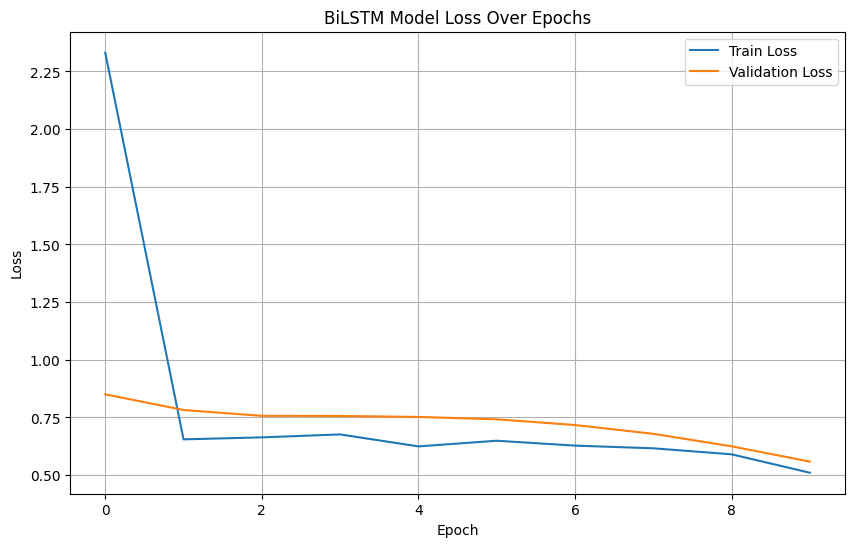

In [86]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('BiLSTM Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('bilstm_loss.png')
plt.show()

- --
## Part 3: Transformer Encoder for Topic Classification
- Dataset Preparation

In [107]:
# defining category keywords in Urdu
category_keywords = {
    'Politics': ['الیکشن', 'حکومت', 'وزیر', 'پارلیمنٹ'],
    'Sports': ['کرکٹ', 'میچ', 'ٹیم', 'کھلاڑی', 'سکور'],
    'Economy': ['مہنگائی', 'تجارت', 'بینک', 'بجٹ', 'جی_ڈی_پی'],
    'International': ['اقوام_متحدہ', 'معاہدہ', 'غیر_ملکی', 'دو_طرفہ', 'تنازع'],
    'Health & Society': ['ہسپتال', 'بیماری', 'ویکسین', 'سیلاب', 'تعلیم']
}


def assign_article_category(article_text_tokens, keywords_map):
    # initializing scores for each category
    category_scores = {}
    for category_name in keywords_map:
        category_scores[category_name] = 0

    # counting keyword occurrences in the article
    for token in article_text_tokens:
        for category_name, keyword_list in keywords_map.items():
            for keyword in keyword_list:
                if token == keyword:
                    category_scores[category_name] += 1

    # finding the category with the highest score
    max_score = -1
    assigned_category = 'General'
    for category_name, score in category_scores.items():
        if score > max_score:
            max_score = score
            assigned_category = category_name

    if max_score == 0:
        assigned_category = 'General'

    return assigned_category

In [104]:
max_sequence_length = 256
transformer_articles_data = []

# re-processing cleaned text to get full articles and their IDs
article_blocks = re.split(r'Article (\d+)', cleaned_text)

# filtering out empty strings from article blocks
filtered_article_blocks = []
for block in article_blocks:
    stripped_block = block.strip()
    if len(stripped_block) > 0:
        filtered_article_blocks.append(stripped_block)
article_blocks = filtered_article_blocks

# iterating through article blocks to extract content and assign categories
for i in range(0, len(article_blocks), 2):
    article_id_str = article_blocks[i]
    content_text = article_blocks[i+1] if (i+1) < len(article_blocks) else ""

    try:
        current_article_id = int(article_id_str)
    except ValueError:
        print(f"warning: could not parse article id from: {article_id_str}. skipping block.")
        continue

    # tokenizing the article content
    article_tokens = tokenizer(content_text)

    # converting tokens to indices and handling unknown words
    token_ids = []
    for token in article_tokens:
        token_id = word_to_index.get(token, word_to_index['<UNK>'])
        token_ids.append(token_id)

    # padding or truncating the token_ids sequence
    if len(token_ids) > max_sequence_length:
        padded_token_ids = token_ids[:max_sequence_length]
    else:
        # padding with the <UNK> token ID, which is 0
        padded_token_ids = token_ids + [word_to_index['<UNK>']] * (max_sequence_length - len(token_ids))

    # assigning a category to the article
    assigned_category = assign_article_category(article_tokens, category_keywords)

    # adding data to the list
    transformer_articles_data.append({
        'article_id': current_article_id,
        'token_ids': padded_token_ids,
        'category': assigned_category
    })

print(f"processed {len(transformer_articles_data)} articles for transformer input.")

# printing a sample of the processed data
print("\nsample of processed article data:")
for i in range(min(3, len(transformer_articles_data))):
    print(f"  article id: {transformer_articles_data[i]['article_id']}, category: {transformer_articles_data[i]['category']}, token_ids[:10]: {transformer_articles_data[i]['token_ids'][:10]}")

processed 275 articles for transformer input.

sample of processed article data:
  article id: 1, category: Politics, token_ids[:10]: [73, 6, 33, 224, 22, 365, 37, 75, 277, 680]
  article id: 2, category: Sports, token_ids[:10]: [735, 1027, 7, 73, 3, 61, 369, 446, 46, 510]
  article id: 3, category: Health & Society, token_ids[:10]: [33, 4, 1143, 549, 10, 916, 59, 11, 603, 50]
